In [15]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [16]:
returns = pd.read_csv(

    "../data/processed/returns.csv",

    index_col=0,

    parse_dates=True

)

regimes = pd.read_csv(

    "../data/processed/regimes.csv",

    index_col=0,

    parse_dates=True

)

allocations = pd.read_csv(

    "../data/processed/optimized_allocations.csv",

    index_col=0

)

regimes.columns = ["Regime"]

returns = returns.loc[regimes.index]

In [17]:
regimes.columns = ["Regime"]
returns = returns.loc[regimes.index]

In [18]:
strategy_returns = []

turnover_history = []

transaction_cost = 0.002

previous_weights = None


for date in returns.index:

    regime = regimes.loc[date, "Regime"]

    weights = allocations[str(regime)].values

    portfolio_return = np.dot(

        returns.loc[date],

        weights

    )

    # ======================================
    # TRANSACTION COSTS
    # ======================================

    if previous_weights is not None:

        turnover = np.abs(

            weights - previous_weights

        ).sum()

        cost = turnover * transaction_cost

    else:

        turnover = 0

        cost = 0

    portfolio_return -= cost

    strategy_returns.append(

        portfolio_return

    )

    turnover_history.append(

        turnover

    )

    previous_weights = weights

In [19]:
strategy_returns = pd.Series(

    strategy_returns,

    index=returns.index,

    name="Strategy"

)

turnover_series = pd.Series(

    turnover_history,

    index=returns.index,

    name="Turnover"

)


In [20]:

strategy_curve = (

    1 + strategy_returns

).cumprod()

benchmark_curve = (

    1 + returns["^NSEI"]

).cumprod()

In [21]:
strategy_returns.to_csv(

    "../data/processed/strategy_returns.csv"

)

strategy_curve.to_csv(

    "../data/processed/strategy_equity_curve.csv"

)

benchmark_curve.to_csv(

    "../data/processed/benchmark_equity_curve.csv"

)

turnover_series.to_csv(

    "../data/processed/turnover.csv"

)

print("Backtest outputs saved.")

Backtest outputs saved.


In [22]:
strategy_total_return = (

    strategy_curve.iloc[-1] - 1

)

benchmark_total_return = (

    benchmark_curve.iloc[-1] - 1

)

print()

print("=" * 50)

print("PERFORMANCE SUMMARY")

print("=" * 50)

print(f"Strategy Total Return: {strategy_total_return:.2%}")

print(f"Benchmark Total Return: {benchmark_total_return:.2%}")


PERFORMANCE SUMMARY
Strategy Total Return: 459.64%
Benchmark Total Return: 266.72%


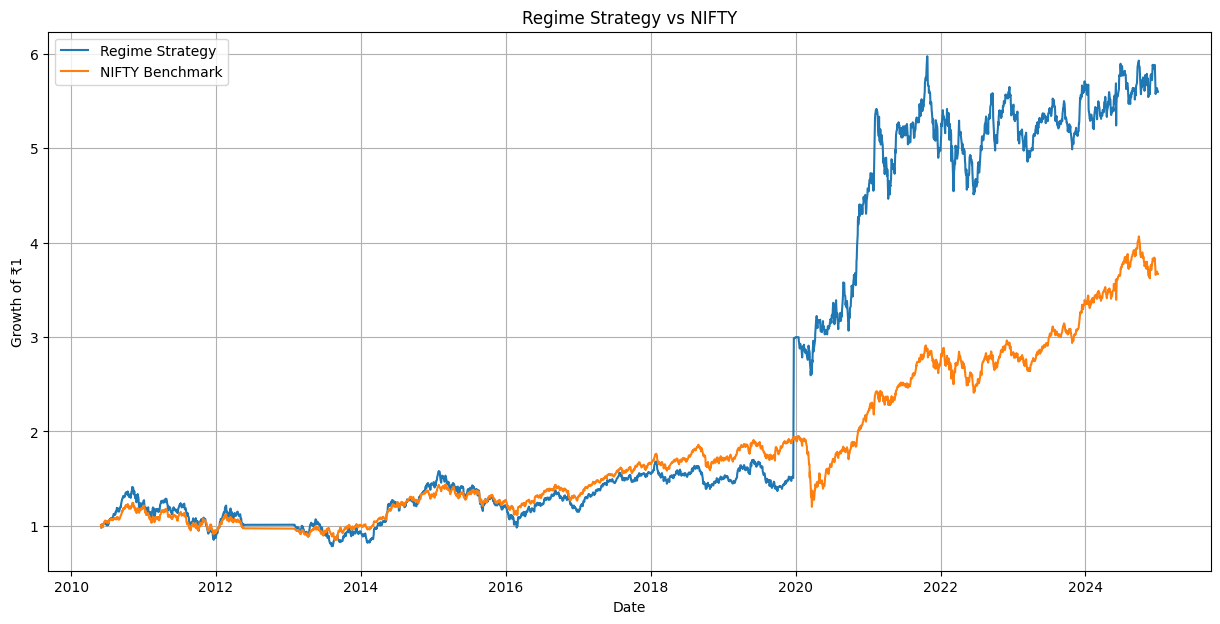

In [23]:
plt.figure(figsize=(15,7))

plt.plot(

    strategy_curve,

    label="Regime Strategy"

)

plt.plot(

    benchmark_curve,

    label="NIFTY Benchmark"

)

plt.legend()

plt.title(

    "Regime Strategy vs NIFTY"

)

plt.xlabel("Date")

plt.ylabel("Growth of ₹1")

plt.grid(True)

plt.savefig(

    "../reports/equity_curve.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()


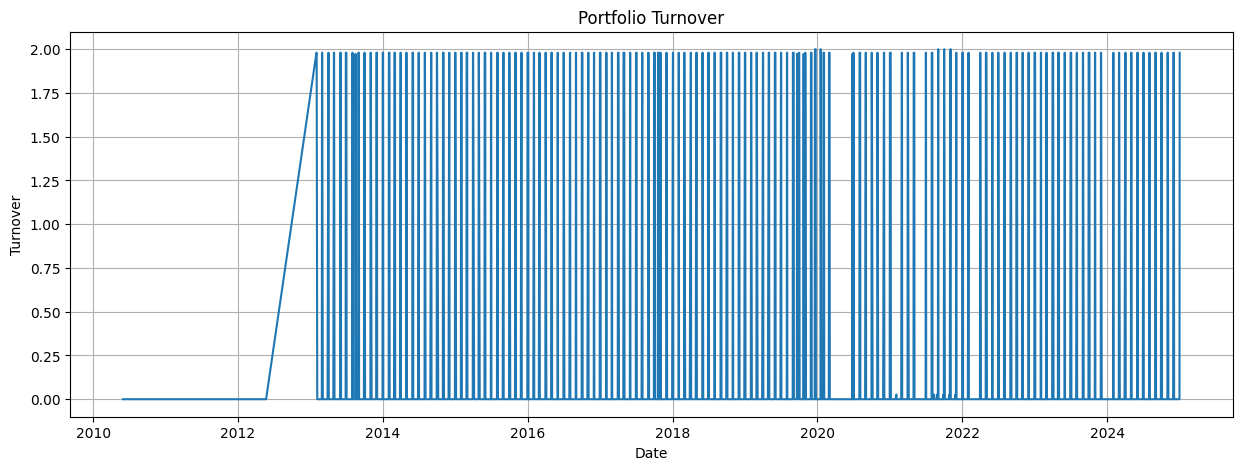

In [24]:
plt.figure(figsize=(15,5))

plt.plot(

    turnover_series

)

plt.title(

    "Portfolio Turnover"

)

plt.xlabel("Date")

plt.ylabel("Turnover")

plt.grid(True)

plt.savefig(

    "../reports/turnover_plot.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()